# Evaluating LLM Response Quality: A Reference-Based Approach to Rank Correlation and Best-of-K Analysis

Author: rab

This notebook implements a dual evaluation framework for LLM top-k responses:

1. Ranking test  
- Uses Spearman correlation to test if model's ordering matches quality-based ordering.  
- *"Does the model know which of its answers are best?"*

2. Top-k content test  
- Finds the single best response within top-K using BLEU/ROUGE/cosine vs gold pool.  
- *"Does the model generate *any* high-quality answer in top-K?"*

Note that both treat gold-standard responses as an unordered pool (takes best match to any gold). Of course, if it is ordered, the quality scores should, assuming good LLM responses, align.  

This separates LLM *self-ranking ability* from *generation quality*, providing complementary evaluations.


In [ ]:
#%pip install pandas scikit-learn sacrebleu sentence-transformers torch rouge-score

In [3]:
import pandas as pd
import numpy as np
import sys
from scipy.stats import spearmanr, bootstrap
from rouge_score import rouge_scorer
from sacrebleu.metrics import BLEU as SacreBLEU
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
#from sentence_transformers import SentenceTransformer
#import evaluate

In [4]:
print("Python version:", sys.version)

Python version: 3.13.9 (main, Oct 28 2025, 12:02:14) [Clang 20.1.4 ]


LLM (Gemini 2.5 Pro) created questions and responses. Note the gold_responses are singular (presumably less work for SMEs), whereas the LLM produced the top 3 responses. However, the SMEs could produce more than one gold-standard reponse as both lists can be evaluated vs each other (LLM vs SME).

In [5]:
test_dict = [
    {
        "question": "What is the capital of France?",
        "llm_responses": ["Edo", "Paris", "London"],
        "gold_responses": ["Paris"]
    },
    {
        "question": "Explain the process of photosynthesis in plants, including the main reactants and products.",
        "llm_responses": [
            "Photosynthesis is the process where plants use sunlight, water, and carbon dioxide to produce glucose and oxygen. The equation is 6CO2 + 6H2O → C6H12O6 + 6O2.",
            "Photosynthesis converts light energy into chemical energy using CO2, water, and chlorophyll to make sugar and oxygen.",
            "Plants make food from sunlight through a process called photosynthesis involving chloroplasts."
        ],
        "gold_responses": ["Photosynthesis converts light energy into chemical energy. Plants take in carbon dioxide from the air and water from the soil, using sunlight and chlorophyll to produce glucose (sugar) and release oxygen as a byproduct."]
    },
    {
        "question": "What are the three main types of rocks found in geology, and how are they formed?",
        "llm_responses": [
            "Igneous, sedimentary, and metamorphic. Igneous form from cooled magma, sedimentary from compressed sediment layers, metamorphic from heat and pressure on existing rocks.",
            "The three types are igneous (from magma), sedimentary (from sediments), and metamorphic (from transformed rocks).",
            "Rocks include granite, limestone, and marble formed through geological processes."
        ],
        "gold_responses": ["The three rock types are igneous (formed by cooling magma/lava), sedimentary (formed by deposition and compaction of sediments), and metamorphic (formed by transformation of existing rocks under intense heat and pressure)."]
    },
    {
        "question": "Describe Newton's three laws of motion in your own words.",
        "llm_responses": [
            "1st: Objects at rest stay at rest unless acted upon. 2nd: Force equals mass times acceleration. 3rd: Every action has an equal opposite reaction.",
            "Newton's laws: 1) Inertia keeps things moving or still, 2) F=ma relates force to motion change, 3) actions create equal reactions.",
            "Three laws govern motion: objects resist change, acceleration depends on force and mass, forces balance in pairs."
        ],
        "gold_responses": ["1. Law of Inertia: Objects resist changes in motion. 2. F=ma: Force is proportional to mass times acceleration. 3. Action-Reaction: Forces come in equal and opposite pairs."]
    },
    {
        "question": "What caused World War I? List the main contributing factors.",
        "llm_responses": [
            "Assassination of Archduke Franz Ferdinand, militarism, alliances, imperialism, nationalism (MAIN acronym).",
            "MAIN causes: Militarism, Alliances, Imperialism, Nationalism, triggered by Archduke assassination.",
            "World War I started from European tensions and the assassination in Sarajevo."
        ],
        "gold_responses": ["World War I was triggered by the assassination of Archduke Franz Ferdinand but caused by militarism, alliances (Triple Entente vs Central Powers), imperialism, and nationalism throughout Europe."]
    },
    {
        "question": "Explain the water cycle, including evaporation, condensation, precipitation, and collection.",
        "llm_responses": [
            "Water evaporates from oceans/lakes, forms clouds through condensation, falls as precipitation (rain/snow), then collects in rivers/oceans to restart the cycle.",
            "Water cycle: evaporation → condensation → precipitation → collection → repeat.",
            "Water moves through evaporation from oceans and precipitation back to earth."
        ],
        "gold_responses": ["The water cycle involves evaporation (liquid to gas), condensation (gas to liquid forming clouds), precipitation (water falling as rain/snow), and collection (water gathering in bodies of water)."]
    },
    {
        "question": "Compare prokaryotic and eukaryotic cells. What are the key differences?",
        "llm_responses": [
            "Prokaryotes: no nucleus, smaller, bacteria. Eukaryotes: have nucleus, larger, plants/animals. Prokaryotes have circular DNA, eukaryotes linear chromosomes.",
            "Prokaryotic cells lack nucleus and organelles; eukaryotic cells have both and are more complex.",
            "Bacteria are prokaryotes without nucleus; plant and animal cells are eukaryotes."
        ],
        "gold_responses": ["Prokaryotic cells lack a nucleus and membrane-bound organelles, are smaller, and include bacteria/archaea. Eukaryotic cells have a nucleus, organelles, are larger, and include plants, animals, fungi."]
    },
    {
        "question": "What is the Krebs cycle and its role in cellular respiration?",
        "llm_responses": [
            "The Krebs cycle (Citric Acid Cycle) occurs in mitochondria, breaks down acetyl-CoA to produce ATP, NADH, FADH2, and CO2 for the electron transport chain.",
            "Krebs cycle oxidizes acetyl-CoA to generate electron carriers for ATP production.",
            "Krebs cycle is part of cellular respiration in mitochondria."
        ],
        "gold_responses": ["The Krebs cycle oxidizes acetyl-CoA from glycolysis, producing CO2, ATP, NADH, and FADH2. These electron carriers then fuel the electron transport chain to generate most of cellular respiration's ATP."]
    },
    {
        "question": "Describe the structure and function of DNA. What are its building blocks?",
        "llm_responses": [
            "DNA is a double helix made of nucleotides (sugar, phosphate, base: A,T,C,G). Stores genetic info, replicates for cell division, transcribed to RNA for protein synthesis.",
            "DNA double helix contains genetic code made from nucleotides with four bases.",
            "DNA stores hereditary information in cells as a twisted ladder structure."
        ],
        "gold_responses": ["DNA (deoxyribonucleic acid) is a double helix composed of nucleotides containing deoxyribose sugar, phosphate, and bases adenine, thymine, cytosine, guanine. It stores and transmits genetic information."]
    },
    {
        "question": "Explain plate tectonics theory and evidence supporting it.",
        "llm_responses": [
            "Earth's crust is broken into plates that move on mantle convection currents. Evidence: continental drift fit, earthquakes/volcanoes at plate boundaries, seafloor spreading, fossil evidence.",
            "Plate tectonics explains continent movement with evidence from earthquakes and ocean floor.",
            "Earth's plates move causing earthquakes and mountain formation."
        ],
        "gold_responses": ["Plate tectonics states that Earth's lithosphere is divided into plates moving atop the asthenosphere. Evidence includes matching continents, magnetic seafloor stripes, earthquake patterns, and GPS measurements of plate motion."]
    },
    {
        "question": "What is machine learning? Differentiate supervised vs unsupervised learning.",
        "llm_responses": [
            "Machine learning trains algorithms on data to make predictions/decisions. Supervised uses labeled data (input-output pairs), unsupervised finds patterns in unlabeled data.",
            "ML learns from data; supervised has labels, unsupervised finds patterns automatically.",
            "Machine learning uses data to train models for predictions."
        ],
        "gold_responses": ["Machine learning enables computers to learn patterns from data without explicit programming. Supervised learning uses labeled training data; unsupervised learning discovers structure in unlabeled data."]
    },
]

Simple string typing

In [6]:
df = pd.DataFrame(test_dict)
df["llm_responses"] = df["llm_responses"].apply(lambda X: [str(x) for x in X])
df["gold_responses"] = df["gold_responses"].apply(lambda X: [str(x) for x in X])

In [7]:
df.head()

,question,llm_responses,gold_responses
0,What is the capital of France?,"[Edo, Paris, London]",[Paris]
1,Explain the process of photosynthesis in plant...,[Photosynthesis is the process where plants us...,[Photosynthesis converts light energy into che...
2,What are the three main types of rocks found i...,"[Igneous, sedimentary, and metamorphic. Igneou...",[The three rock types are igneous (formed by c...
3,Describe Newton's three laws of motion in your...,[1st: Objects at rest stay at rest unless acte...,[1. Law of Inertia: Objects resist changes in ...
4,What caused World War I? List the main contrib...,"[Assassination of Archduke Franz Ferdinand, mi...",[World War I was triggered by the assassinatio...


In [8]:
df_orig = df.copy()

## Define text-based scoring functions

**Text similarity metrics used:**
- BLEU Score: Calculates the SacreBLEU score, which measures n-gram precision between a prediction and a reference, useful for evaluating translation quality.
- ROUGE-L F1 Score: Computes the F1-score for ROUGE-L, which is based on the longest common subsequence between a prediction and a reference, often used for summarization evaluation.
- Cosine similarity: *cosine_sim(a,b) = (a · b) / (‖a‖ ‖b‖)*, where *a · b* is the dot product and *‖a‖ ‖b‖* are the Euclidean (L2) norms

BLEU and ROUGE

In [9]:
# BLEU between [0,1]
sacre_bleu = SacreBLEU(effective_order=True)

def bleu_score(pred: str, ref: str) -> float:
    # SacreBLEU args: predictions=[pred], references=[[ref]]
    return sacre_bleu.corpus_score([pred], [[ref]]).score / 100.0

In [10]:
# ROUGE-L (F1) between [0,1]
rouge = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)

def rouge_l_f1(pred: str, ref: str) -> float:
    scores = rouge.score(ref, pred)
    return scores["rougeL"].fmeasure

**Cosine similarity**

It measures the angle between two text vectors; a smaller angle means the vectors are pointing in a more similar direction, which signifies that the original texts are more alike in their meaning.
- A score of 1.0 means texts are identical in meaning.
- A score of 0.0 means texts are unrelated.
- A score of -1.0 means texts have opposite meanings.

In [11]:
def cosine_sim(a, b) -> float:
    denom = (np.linalg.norm(a) * np.linalg.norm(b)) #computes Euclidean norm (L2 norm) of embeddings
    if denom == 0.0:
        return 0.0
    return float(np.dot(a, b) / denom) #np.dot() computes dot product

**TF-IDF embeddings**

Text comparisons using TF-IDF with cosine similarity, which first converts texts into numerical TF-IDF vectors (Term Frequency-Inverse Document Frequency) that weigh words by importance. In this case, common words like "the" get low weights, rare words get high weights. From these vectors, measure the cosine of the angle between those vectors overlap. In short, TF-IDF cosine similarity asks "Do these texts discuss the *same topics* using similar keyword patterns?" It's robust to word order and exact phrasing but sensitive to vocabulary choice. Perfect match = 1.0, no overlap = 0.0.

- TF-IDF
   - Counts word occurrences (TF) and downweights frequent words across documents (IDF)
   - Creates sparse vectors where each dimension = unique word, value = importance score

In [12]:
# TF-IDF cosine similarity
def tfidf_cosine_sim(pred: str, ref: str) -> float:
    try:
        vectorizer = TfidfVectorizer().fit_transform([pred, ref])
        return cosine_similarity(vectorizer[0:1], vectorizer[1:2])[0,0]
    except ValueError:
        return 0.0

SentenceTransformer embeddings (TBD)

In [0]:
# Embedding cosine similarity
# model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

# def embedding_cosine_similarity(pred: str, ref: str) -> float:
#     emb = model.encode([pred, ref], convert_to_numpy=True)
#     return cosine_sim(emb[0], emb[1])

## Combined LLM Response Quality vs Gold Standard: Rank Correlation

The below code calculates the average Spearman rank correlation coefficient between the rankings produced by a LLM and the rankings derived from a set of "gold standard" responses. Specifically, it assesses how well the model's predicted order of responses aligns with the order of responses based on their quality scores (proxy ordering), which are computed using various metrics (BLEU, ROUGE, and cosine similarity).
- The model generates a list of responses (LLM responses) and compares them against a set of reference answers (gold responses).
- For each response, a combined quality score is calculated, and the rankings of these scores are compared to the model's predicted rankings.
- The Spearman correlation measures the strength and direction of the association between the two rankings.

Again, as outlined below, this process checks if the LLM is good at ordering its own answers from best to worst. It compares the LLM's preferred order to a "true" quality order derived from scoring its answers against a correct "gold standard" response.

In short, we're asking: Does the LLM know which of its answers is the best?

1.  Get LLM's recommendation order
    -   The LLM provides a list of responses (assuming the first one is its most recommended).
    -   Example:
        -   Question: "What is 2+2?"
        -   LLM Answers: `["4", "An even number", "3+1"]`
        -   LLM's Ranks: `[0, 1, 2]`

2.  Score Each Answer
    -   Each LLM answer is given a quality score by comparing it to the gold standard answer (4 in this running example).
    -   Example:
        -   Gold Answer: `4`
        -   Quality Scores: `[1.0, 0.5, 0.9]`

3.  Find "True" Quality Order
    -   We then rank the LLM's answers based on their quality scores, from highest to lowest.
    -   Example: 
        - Based on the scores, the best answer is `4` (1.0 score), then `3+1` (0.9 score), then `An even number` (0.5 score).
        - "True" Ranks: `[0, 2, 1]`

4.  Compare the Rankings
    -   We use a statistical test (Spearman's rank correlation) to see how well the LLM's order matches the "true" quality order [1].
        | ρ value | Meaning |
        |---------|---------|
        | +1.0 | Perfect agreement |
        | +0.5 | Moderate agreement |
        | 0.0 | No correlation |
        | -1.0 | Perfectly reversed |
    -   Example:
        -   LLM's Ranks: `[0, 1, 2]`
        -   "True" Ranks: `[0, 2, 1]`
        -   The correlation will be positive but not perfect, because the LLM mistakenly ranked "An even number" (rank 1) higher than "3+1" (rank 2).

A high correlation score means the LLM is great at identifying its best recommendations correctly and putting it first. A low score means its recommendation evaluation (ordering) is poor.

**Expected outcome**

Single number: average Spearman correlation across all examples, where
- High (>0.7) meaning that the LLM is good at self-ranking vs the gold standard putting good responses first
- Low (<0.3) meant that the LLM is poor at self-ranking putting poor responses first

**Some assumptions**
- `llm_responses` ordered by LLM's preference (0 = best)
- `gold_responses` unordered pool of reference responses (**their order irrelevant**)
  - The gold standard responses are not assumed to be in a ranked order of quality.
  - Quality derived from similarity metrics, not human judgment
  - Proxy gold ranking built from scores assumes higher similarity = better alignment with gold standard
  - AND this quality score approach is more flexible. "How close is this LLM response to any of the correct answers?" In answering this, it allows for variations in phrasing, verbiage, and structure while still measuring closeness to the SME ground truth.

**References**

[1] Volk-Jesussek, Hannah. "Spearman Correlation: A Beginner’s Guide." numiqo. Last updated January 26, 2026. https://numiqo.com/tutorial/spearman-correlation.

In [13]:
# For multiple golds, a simple, intuitive choice is "best match to any gold" is the path chosen!
# Or, take best match to any gold (where order doesn't matter)
def best_match(metric_fn, pred: str, golds: list[str]) -> float:
    return max(metric_fn(pred, g) for g in golds)

In [14]:
def combined_quality_score(pred: str, golds: list[str]) -> float:
    # score pred vs all golds using these metrics; take the top match per metric, then average
    b = best_match(bleu_score, pred, golds)
    r = best_match(rouge_l_f1, pred, golds)
    c = best_match(tfidf_cosine_sim, pred, golds) #or using embeddings
    return (b + r + c) / 3.0 #simple average

# gold_responses is an unordered list of reference answers. combined_quality_score() compares pred against all of them and takes the highest similarity score from any gold; in other words, it evaluates if LLM's ordering matches score-aligned "gold" ordering
def evaluate_ranking_by_row(llm_responses: list[str], gold_responses: list[str]):
    n = len(llm_responses)
    if n <= 1: #single LLM response
        return {"spearman": np.nan, 
                "gold_scores": [combined_quality_score(llm_responses[0], gold_responses)]}

    # compute gold_scores for each LLM response (best match vs gold standard pool)
    gold_scores = [combined_quality_score(pred, gold_responses) for pred in llm_responses]

    # indices in model's predicted order (0 is the top one, then 1, 2, 3, ...)
    # LLM's predicted ranks (assumes list order provided is the LLM's ranking)
    predicted_ranks = np.arange(n)

    # Build proxy "gold" ranking by sorting scores, where gold responses treated as unordered pool
    # Or, dynamic ranking from scores between LLM and gold responses
    gold_order = np.argsort(-np.array(gold_scores)) 
    gold_ranks = np.empty(n, dtype=int)
    for rank_pos, idx in enumerate(gold_order):
        gold_ranks[idx] = rank_pos

    # Spearman correlation between model order and gold-based order
    spearman_corr, _ = spearmanr(predicted_ranks, gold_ranks)

    return {"spearman": float(spearman_corr), "gold_scores": gold_scores, "gold_ranks": gold_ranks.tolist()}

In [15]:
ranking_results = df.apply(lambda row: evaluate_ranking_by_row(row["llm_responses"], row["gold_responses"]), axis=1)

In [16]:
df["spearman_rank_corr"] = ranking_results.apply(lambda r: r["spearman"])
df["gold_scores"] = ranking_results.apply(lambda r: r["gold_scores"])
df["gold_ranks"] = ranking_results.apply(lambda r: r.get("gold_ranks"))

print(f"Avg Spearman rank corr: {np.nanmean(df['spearman_rank_corr']):.3f}")

Avg Spearman rank corr: 0.545


## Combined LLM Response Quality vs Gold Standard: Best-of-k Metrics

The below process checks if the LLM managed to produce at least one high-quality recommendation within its top `k` attempts, ignoring the order. It finds the LLM response that is still good but maybe not ranked as high (i.e. the proverbial "diamond in the rough").

In short, we're asking: Did the LLM generate *any* good answers in the bunch?

1.  Get Top `k` answers
    - We take a subset of the LLM's best guesses (e.g. the top 3 or 5).
    - Example:
        - Question: "What color is the sky?"
        - LLM's Top 3 Answers: `["The sky is blue.", "Azure.", "The color of the ocean."]`

2.  Find the best score
    - For each response in the group, we calculate its quality score against the gold standard (similar to above). Then, we find the single highest score among them.
    - Example:
        - Gold Answer: "Blue"
        - Quality Scores: `[0.9, 0.8, 0.6]`
        - Best Score in the group: `0.9`

3.  Report the best score
    - The single best score is reported for that grouping. This is repeated for every question and averaged.
    - Example:
        - The best quality the model achieved for this question was 0.9. 
        - This tells us it's capable of generating a very good answer, even if it wasn't its #1 pick.

This metric is useful because even if an LLM is bad at ranking its own responses, it might still be generating high-quality content. In other words, it tells us if a good enough answer exists in its recommendations.

**Expected outcome**

Three metric results showing best achievable quality (i.e. best similarity to all gold-standard responses) within each LLM's top-K responses

**Some assumptions**
- Again, LLM responses ordered by model preference (0 = best), and
- Gold-standard responses are an unordered pool (order irrelevant)
- Note that: Higher = better for all metrics

In [18]:
def best_topk(llm_responses: list[str], gold_responses: list[str], k: int = 1):
    # take top-K responses from LLM's ordered list
    k = min(k, len(llm_responses))
    subset = llm_responses[:k]
    if not subset:
        return {"best_bleu": 0.0, "best_rougeL_f1": 0.0, "best_cosine_sim": 0.0}

    # find the best response within top-k for each metric separately, or
    # for each of k responses get best match to any gold, i.e. pick highest of those k scores
    best_bleu = max(best_match(bleu_score, pred, gold_responses) for pred in subset)
    best_rouge = max(best_match(rouge_l_f1, pred, gold_responses) for pred in subset)
    best_cosine = max(best_match(tfidf_cosine_sim, pred, gold_responses) for pred in subset) #or use embeddings

    return {"best_bleu": best_bleu, "best_rougeL_f1": best_rouge, "best_cosine_sim": best_cosine}

In [19]:
k = 1

best1_results = df.apply(lambda row: best_topk(row["llm_responses"], row["gold_responses"], k=k), axis=1)

for metric in ["best_bleu", "best_rougeL_f1", "best_cosine_sim"]:
    df[f"{metric}_top{k}"] = best1_results.apply(lambda mlist: mlist[metric])

print(f"Avg BLEU@{k}:       {df['best_bleu_top1'].mean():.3f}")
print(f"Avg ROUGE-L F1@{k}: {df['best_rougeL_f1_top1'].mean():.3f}")
print(f"Avg CosineSim@{k}:  {df['best_cosine_sim_top1'].mean():.3f}")

Avg BLEU@1:       0.092
Avg ROUGE-L F1@1: 0.364
Avg CosineSim@1:  0.284


In [20]:
k = 3

best3_results = df.apply(lambda row: best_topk(row["llm_responses"], row["gold_responses"], k=k), axis=1)

for metric in ["best_bleu", "best_rougeL_f1", "best_cosine_sim"]:
    df[f"{metric}_top{k}"] = best3_results.apply(lambda mlist: mlist[metric])

print(f"Avg BLEU@{k}:       {df['best_bleu_top3'].mean():.3f}")
print(f"Avg ROUGE-L F1@{k}: {df['best_rougeL_f1_top3'].mean():.3f}")
print(f"Avg CosineSim@{k}:  {df['best_cosine_sim_top3'].mean():.3f}")

Avg BLEU@3:       0.205
Avg ROUGE-L F1@3: 0.498
Avg CosineSim@3:  0.448


### Bootstrap Confidence

The below function computes a bootstrap confidence interval for the mean of a sample using resampling with replacement. It first converts to an array, then draws `n` bootstrap samples of the same size as the original input data and computes the mean of each resample and confidence intervals via the `bootstrap` function. This works since a bootstrap distribution of the statistic (input value) approximates its true sampling distribution, thus the CIs (of the mean) provide a decent estimate of the confidence interval for the population mean.

In [21]:
cnames = ['spearman_rank_corr', 'best_bleu_top1', 'best_rougeL_f1_top1', 'best_cosine_sim_top1',
          'best_bleu_top3', 'best_rougeL_f1_top3', 'best_cosine_sim_top3',]

ci = []
r = np.random.default_rng(1984)

for c in cnames:
    x = pd.Series(df[c]).dropna().to_numpy(dtype=float)
    resamp = bootstrap(data=(x,), statistic=np.mean, confidence_level=0.95, 
                       n_resamples=50000, random_state=r, method="bca",)
    ci.append((c, x.mean(), resamp.confidence_interval.low, resamp.confidence_interval.high))

ci_df = pd.DataFrame(ci, columns=["Metric", "Mean", "95% CI Lower", "95% CI Upper"])
ci_df

,Metric,Mean,95% CI Lower,95% CI Upper
0,spearman_rank_corr,0.545455,0.045455,0.772727
1,best_bleu_top1,0.091919,0.061238,0.124571
2,best_rougeL_f1_top1,0.364200,0.241831,0.416294
3,best_cosine_sim_top1,0.284476,0.199427,0.357891
4,best_bleu_top3,0.205261,0.113738,0.483390
5,best_rougeL_f1_top3,0.498317,0.433170,0.666658
6,best_cosine_sim_top3,0.448139,0.353945,0.621460


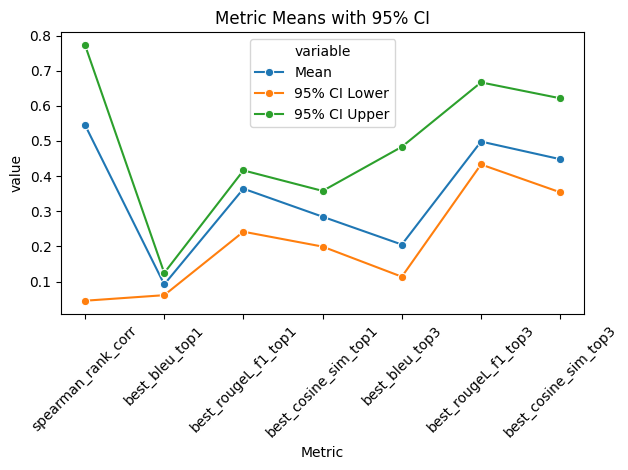

In [22]:
df_long_ci = ci_df.melt(id_vars=["Metric"], value_vars=['Mean', '95% CI Lower', '95% CI Upper'], )

sns.lineplot(data=df_long_ci, x='Metric', y='value', hue='variable', marker='o',)
plt.title("Metric Means with 95% CI")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Pairwise Response Comparison

Creates pairwise score matrices between all LLM responses and all "gold" responses for each question. For every question, it takes each LLM-generated responses and compares it individually against every single "gold standard" answer, calculating three similarity scores (BLEU, ROUGE-L, and Cosine Similarity) for each pairing.

Each output gives you a head-to-head comparison moving past high-level averaging. Look for rows where the scores are high (e.g. >= 0.7). This indicates that the specific LLM response in that row is a very close match to the corresponding "gold standard" response. Low scores mean the two are not similar. More specifically:
- You can see which of the LLM's responses were successful because they will have high scores against at least one gold response.
- Low scores across the board for a particular LLM response mean it completely failed.
- It shows you which "gold standard" phrasing the LLM's response most closely matched, helping understand any syntatical nuances.

In [23]:
def pairwise_comparison(df):
    df_lst = []

    for item in df:
        question = item["question"]
        llm_responses = item["llm_responses"]
        gold_responses = item["gold_responses"]

        table = []
        for llm_res in llm_responses:
            for gold_res in gold_responses:
                b_score = bleu_score(llm_res, gold_res)
                r_score = rouge_l_f1(llm_res, gold_res)
                c_score = tfidf_cosine_sim(llm_res, gold_res)
                table.append({"Question": question, "LLM Response": llm_res, "Gold Response": gold_res, 
                              "BLEU Score": b_score, "ROUGE-L Score": r_score, 
                              "Cosine Similarity": c_score, })
        tmp = pd.DataFrame(table)
        df_lst.append(tmp)

    return df_lst

In [24]:
response_scores = pairwise_comparison(test_dict)

In [25]:
response_scores_df = pd.concat(response_scores, ignore_index=True)
response_scores_df["Group"] = response_scores_df["Question"].astype('category').cat.codes
response_scores_df.sort_values(by=["Group"]).head(10)

,Question,LLM Response,Gold Response,BLEU Score,ROUGE-L Score,Cosine Similarity,Group
20,Compare prokaryotic and eukaryotic cells. What...,Bacteria are prokaryotes without nucleus; plan...,Prokaryotic cells lack a nucleus and membrane-...,0.007631,0.256410,0.361890,0
19,Compare prokaryotic and eukaryotic cells. What...,Prokaryotic cells lack nucleus and organelles;...,Prokaryotic cells lack a nucleus and membrane-...,0.040320,0.476190,0.591256,0
18,Compare prokaryotic and eukaryotic cells. What...,"Prokaryotes: no nucleus, smaller, bacteria. Eu...",Prokaryotic cells lack a nucleus and membrane-...,0.043227,0.434783,0.206712,0
9,Describe Newton's three laws of motion in your...,1st: Objects at rest stay at rest unless acted...,1. Law of Inertia: Objects resist changes in m...,0.090816,0.301887,0.197659,1
10,Describe Newton's three laws of motion in your...,Newton's laws: 1) Inertia keeps things moving ...,1. Law of Inertia: Objects resist changes in m...,0.050058,0.384615,0.159764,1
11,Describe Newton's three laws of motion in your...,Three laws govern motion: objects resist chang...,1. Law of Inertia: Objects resist changes in m...,0.023545,0.391304,0.353427,1
24,Describe the structure and function of DNA. Wh...,DNA is a double helix made of nucleotides (sug...,DNA (deoxyribonucleic acid) is a double helix ...,0.148408,0.444444,0.240625,2
26,Describe the structure and function of DNA. Wh...,DNA stores hereditary information in cells as ...,DNA (deoxyribonucleic acid) is a double helix ...,0.007449,0.162162,0.103006,2
25,Describe the structure and function of DNA. Wh...,DNA double helix contains genetic code made fr...,DNA (deoxyribonucleic acid) is a double helix ...,0.015557,0.263158,0.206084,2
29,Explain plate tectonics theory and evidence su...,Earth's plates move causing earthquakes and mo...,Plate tectonics states that Earth's lithospher...,0.004192,0.307692,0.109484,3


Plot the pairwise scores grouping by the questions. Using `relplot` for ease of facetting (https://seaborn.pydata.org/generated/seaborn.relplot.html).

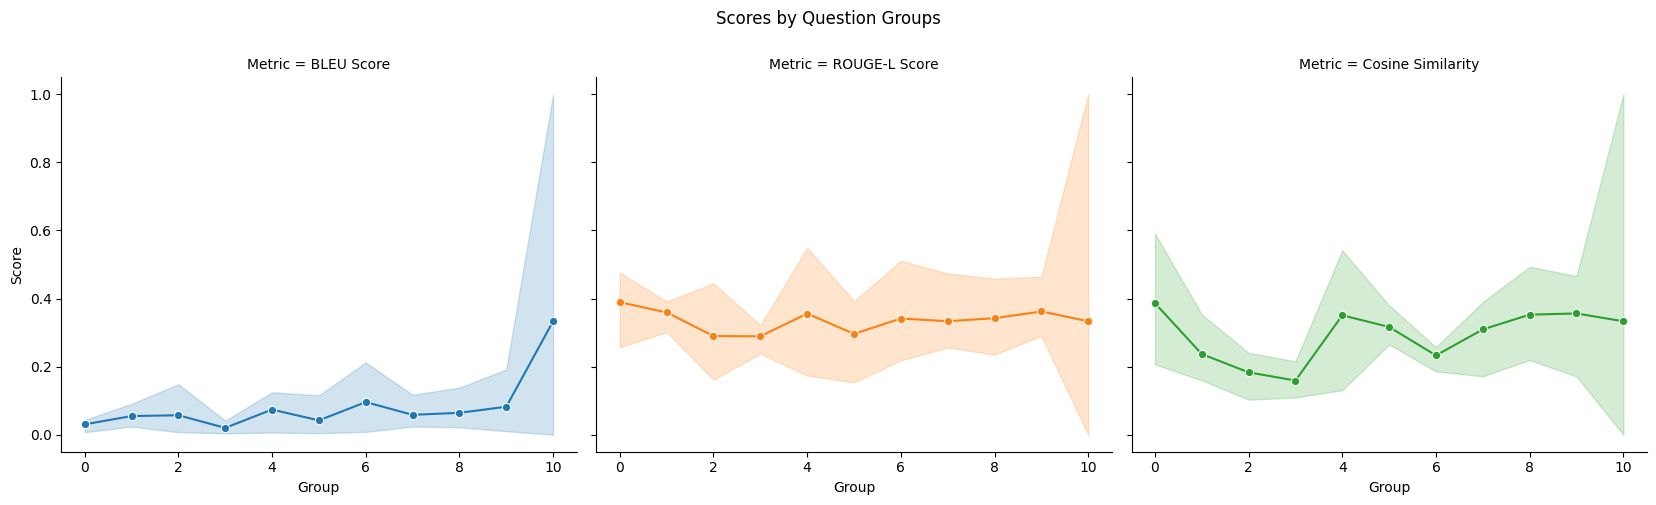

In [26]:
df_long = response_scores_df.melt(id_vars=["Group"], value_vars=["BLEU Score", "ROUGE-L Score", "Cosine Similarity"],
                                  var_name="Metric", value_name="Score", )

p = sns.relplot(data=df_long, x="Group", y="Score", hue="Metric", col="Metric", kind="line",
                marker="o", col_wrap=3, height=5, facet_kws={"sharey": True}, )
p.legend.remove() 
p.fig.suptitle("Scores by Question Groups", y=1)
plt.tight_layout()
plt.show()